In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessed data imports

In [4]:
import numpy as np
import pandas as pd
import joblib

X_train = np.load("C:/Users/Saket Gatyan/Downloads/LOL/X_train_bal.npy")
X_test = np.load("C:/Users/Saket Gatyan/Downloads/LOL/X_test.npy")
y_train = np.load("C:/Users/Saket Gatyan/Downloads/LOL/y_train_bal.npy")
y_test = np.load("C:/Users/Saket Gatyan/Downloads/LOL/y_test.npy")

In [5]:
print(y_train)
print(f"Shape: {X_train.shape}")
print(f"Data type: {X_train.dtype}")

[0 0 2 ... 2 2 2]
Shape: (326838, 17)
Data type: float64


# USED BELOW TO EXTRACT FEATURES LIST

In [26]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Original input features as identified by the user (excluding target 'delivery_status')
original_input_features = [
    'day_of_week', 'is_peak_hour', 'warehouse_region', 'delivery_type',
    'shipment_distance_km', 'traffic_level', 'weather_severity',
    'courier_load_pct', 'warehouse_time_hrs', 'order_volume', 'past_delay_rate'
]

# Create a dummy DataFrame to simulate the original X_train structure and dtypes.
# The values are chosen to ensure OneHotEncoder sees all typical categories
# and matches the final 17 feature count based on common cardinalities.
# Assumed cardinalities to match 17 features:
#   warehouse_region: 2 unique values (e.g., 'A', 'B')
#   delivery_type: 2 unique values (e.g., 'Type1', 'Type2')
#   traffic_level: 3 unique values (e.g., 'Low', 'Medium', 'High')
#   weather_severity: 3 unique values (e.g., 'Mild', 'Moderate', 'Severe')
#   day_of_week and is_peak_hour are treated as numerical (int64) as per select_dtypes logic.

dummy_data_for_ct = {
    'day_of_week': [0, 1, 2, 3, 4, 5, 6], # int64, treated as numerical
    'is_peak_hour': [0, 1, 0, 1, 0, 1, 0], # int64, treated as numerical
    'warehouse_region': ['A', 'B', 'A', 'B', 'A', 'B', 'A'], # object, categorical (2 categories)
    'delivery_type': ['Type1', 'Type2', 'Type1', 'Type2', 'Type1', 'Type2', 'Type1'], # object, categorical (2 categories)
    'shipment_distance_km': [10.5, 20.3, 5.1, 30.0, 15.2, 8.9, 25.7], # float64, numerical
    'traffic_level': ['Low', 'Medium', 'High', 'Low', 'Medium', 'High', 'Low'], # object, categorical (3 categories)
    'weather_severity': ['Mild', 'Moderate', 'Severe', 'Mild', 'Moderate', 'Severe', 'Mild'], # object, categorical (3 categories)
    'courier_load_pct': [0.5, 0.8, 0.3, 0.9, 0.6, 0.4, 0.7], # float64, numerical
    'warehouse_time_hrs': [2.1, 3.5, 1.0, 4.2, 2.8, 1.5, 3.9], # float64, numerical
    'order_volume': [100, 250, 50, 300, 150, 75, 200], # int64, numerical
    'past_delay_rate': [0.1, 0.2, 0.05, 0.3, 0.15, 0.08, 0.25] # float64, numerical
}

dummy_X_train_df = pd.DataFrame(dummy_data_for_ct)

# Identify numerical and categorical features based on dtypes, mirroring the user's preprocessing script
numerical_features_derived = dummy_X_train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_derived = dummy_X_train_df.select_dtypes(include=["object"]).columns.tolist()

# Recreate the ColumnTransformer
preprocessor_for_names = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_derived),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_derived)
    ]
)

# Fit on dummy data to get the transformed feature names
preprocessor_for_names.fit(dummy_X_train_df)

# Get the feature names after transformation
feature_names_list = preprocessor_for_names.get_feature_names_out().tolist()

print("Generated Feature Names (total 17):")
print(feature_names_list)

Generated Feature Names (total 17):
['num__day_of_week', 'num__is_peak_hour', 'num__shipment_distance_km', 'num__courier_load_pct', 'num__warehouse_time_hrs', 'num__order_volume', 'num__past_delay_rate', 'cat__warehouse_region_A', 'cat__warehouse_region_B', 'cat__delivery_type_Type1', 'cat__delivery_type_Type2', 'cat__traffic_level_High', 'cat__traffic_level_Low', 'cat__traffic_level_Medium', 'cat__weather_severity_Mild', 'cat__weather_severity_Moderate', 'cat__weather_severity_Severe']


# IGNORE ABOVE

In [ ]:
# !pip install lightgbm
# !pip install xgboost

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import time

# Chosen Models

In [10]:
models = {
    # "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),

    # "Random Forest": RandomForestClassifier(
    #     n_estimators=300,
    #     random_state=42,
    #     n_jobs=-1
    # ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        random_state=42
    ),

    # "Gradient Boosting": GradientBoostingClassifier(
    #     n_estimators=200,
    #     learning_rate=0.1,
    #     max_depth=3,
    #     random_state=42
    # ),

    # "Linear SVM": LinearSVC(
    #     C=1.0,
    #     random_state=42
    # ),

    "LightGBM": LGBMClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    # "MLP": MLPClassifier(
    #     hidden_layer_sizes=(128, 64),
    #     activation="relu",
    #     solver="adam",
    #     max_iter=50,
    #     random_state=42
    # )
}

# Raw Model Training

In [ ]:
results = []

for name, model in models.items():
    print(f"/nTraining {name}...")

    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Training Time (s)": training_time
    })

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Training HistGradientBoosting...
HistGradientBoosting Accuracy: 0.9304
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     27236
           1       0.85      0.87      0.86      9688
           2       0.89      0.94      0.91      3076

    accuracy                           0.93     40000
   macro avg       0.90      0.92      0.91     40000
weighted avg       0.93      0.93      0.93     40000


Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.080183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2471
[LightGBM] [Info] Number of data points in the train set: 326838, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.9273
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     27236
           1       0.83      0.88      0.85      9688
           2       0.88      0.95      0.91      3076

    accuracy                           0.93     40000
   macro avg       0.89      0.92      0.91     40000
weighted avg       0.93      0.93      0.93     40000


Training XGBoost...
XGBoost Accuracy: 0.9224
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27236
           1       0.81      0.88      0.85      9688
           2       0.85      0.96      0.90      3076

    accuracy                           0.92     40000
   macro avg       0.88      0.92      0.90     40000
weighted avg       0.93      0.92      0.92     40000



# Model Evaluation

In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Training Time (s)
0,HistGradientBoosting,0.930400,0.910428,0.930870,0.900878,0.920611,44.032648
1,LightGBM,0.927325,0.907872,0.928232,0.893014,0.924391,15.725679
2,XGBoost,0.922425,0.901003,0.923717,0.880877,0.924366,28.275000


# HGB Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import randint, uniform

hgb = HistGradientBoostingClassifier(random_state=42)

param_dist_hgb = {
    "max_iter": randint(150, 350),
    "learning_rate": uniform(0.03, 0.12),
    "max_depth": randint(3, 8),
    "min_samples_leaf": randint(20, 100),
    "l2_regularization": uniform(0.0, 1.0)
}

hgb_search = RandomizedSearchCV(
    hgb,
    param_distributions=param_dist_hgb,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

hgb_search.fit(X_train, y_train)

print("Best HGB Params:", hgb_search.best_params_)
print("Best HGB CV Score:", hgb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

best_hgb = hgb_search.best_estimator_

y_pred_hgb = best_hgb.predict(X_test)

print("Tuned HGB Accuracy:", accuracy_score(y_test, y_pred_hgb))
print(classification_report(y_test, y_pred_hgb))

# LGBM Tuning

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

param_dist_lgbm = {
    "n_estimators": randint(150, 400),
    "learning_rate": uniform(0.03, 0.12),
    "max_depth": randint(3, 10),
    "num_leaves": randint(20, 80),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

lgbm_search = RandomizedSearchCV(
    lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=25,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

print("Best LGBM Params:", lgbm_search.best_params_)
print("Best LGBM CV Score:", lgbm_search.best_score_)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import pandas as pd

# Best tuned model
best_lgbm = lgbm_search.best_estimator_

# Predictions
y_pred_lgbm = best_lgbm.predict(X_test)

# Metrics
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_macro_f1 = f1_score(y_test, y_pred_lgbm, average="macro")
lgbm_weighted_f1 = f1_score(y_test, y_pred_lgbm, average="weighted")

print("===== Tuned LightGBM Results =====")
print("Accuracy:", lgbm_accuracy)
print("Macro F1:", lgbm_macro_f1)
print("Weighted F1:", lgbm_weighted_f1)
print("/nClassification Report:/n")
print(classification_report(y_test, y_pred_lgbm))

print("/nConfusion Matrix:/n")
print(confusion_matrix(y_test, y_pred_lgbm))

# XGB Tuning

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist_xgb = {
    "n_estimators": randint(150, 400),
    "learning_rate": uniform(0.03, 0.12),
    "max_depth": randint(3, 8),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 0.5)
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=25,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best XGB CV Score:", xgb_search.best_score_)


In [ ]:
# Best tuned model
best_xgb = xgb_search.best_estimator_

# Predictions
y_pred_xgb = best_xgb.predict(X_test)

# Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_macro_f1 = f1_score(y_test, y_pred_xgb, average="macro")
xgb_weighted_f1 = f1_score(y_test, y_pred_xgb, average="weighted")

print("===== Tuned XGBoost Results =====")
print("Accuracy:", xgb_accuracy)
print("Macro F1:", xgb_macro_f1)
print("Weighted F1:", xgb_weighted_f1)
print("/nClassification Report:/n")
print(classification_report(y_test, y_pred_xgb))

print("/nConfusion Matrix:/n")
print(confusion_matrix(y_test, y_pred_xgb))

# Final tuned results

In [ ]:
tuning_results = pd.DataFrame([
    {
        "Model": "HistGradientBoosting (Tuned)",
        "Accuracy": accuracy_score(y_test, best_hgb.predict(X_test)),
        "Macro F1": f1_score(y_test, best_hgb.predict(X_test), average="macro")
    },
    {
        "Model": "LightGBM (Tuned)",
        "Accuracy": lgbm_accuracy,
        "Macro F1": lgbm_macro_f1
    },
    {
        "Model": "XGBoost (Tuned)",
        "Accuracy": xgb_accuracy,
        "Macro F1": xgb_macro_f1
    }
])

tuning_results.sort_values(by="Macro F1", ascending=False)

# Exporting models for API

In [7]:
import joblib

joblib.dump(best_hgb, "hgb_model.joblib")
joblib.dump(best_lgbm, "lgbm_model.joblib")
# joblib.dump(models["Random Forest"], "rf_model.joblib")
joblib.dump(models["MLP"], "mlp_model.joblib")
joblib.dump(best_xgb, "xgb_model.joblib")

NameError: name 'best_hgb' is not defined

# NEW

In [8]:
tuned_models = {
    "HistGradientBoosting (Tuned)": best_hgb,
    "LightGBM (Tuned)": best_lgbm,
    "XGBoost (Tuned)": best_xgb
}

'''tuned_models = {
    "HistGradientBoosting (Tuned)": models["HistGradientBoosting"],
    "LightGBM (Tuned)": models["LightGBM"],
    "XGBoost (Tuned)": models["XGBoost"]
}'''

NameError: name 'best_hgb' is not defined

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)
from sklearn.preprocessing import label_binarize

# Set a professional style for plots
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})

CLASS_NAMES = ['On-Time', 'At-Risk', 'Delayed']
N_CLASSES = len(CLASS_NAMES)

In [16]:
def plot_confusion_matrix(model_name, y_true, y_pred, class_names, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f'Confusion Matrix for {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

In [17]:
def plot_roc_curve(model_name, y_true, y_score, class_names, n_classes, ax):
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'ROC curve of class {class_names[i]} (area = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Receiver Operating Characteristic (OvR) for {model_name}')
    ax.legend(loc="lower right")

In [18]:
def plot_precision_recall_curve(model_name, y_true, y_score, class_names, n_classes, ax):
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        disp = PrecisionRecallDisplay(precision=precision, recall=recall)
        disp.plot(ax=ax, name=f'Class {class_names[i]}')

    ax.set_title(f'Precision-Recall Curve (OvR) for {model_name}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

In [19]:
def plot_feature_importance(model_name, model, feature_names, top_n=20, ax=None):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        if isinstance(model, (type(LGBMClassifier()), type(XGBClassifier()))):
            # For tree-based models like LightGBM and XGBoost, higher is more important.
            # We can use the raw importances.
            pass
        else:
            # For other models, if feature_importances_ exists but is not directly interpretable as such, or needs scaling.
            # For consistency, we assume higher is better, but this might need adjustment for non-tree models.
            pass

        feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(top_n)

        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))

        sns.barplot(x='importance', y='feature', data=feature_importance_df, ax=ax, palette='viridis')
        ax.set_title(f'Top {top_n} Feature Importances for {model_name}')
        ax.set_xlabel('Importance')
        ax.set_ylabel('Feature')
        plt.tight_layout()
    else:
        print(f"Warning: {model_name} does not have 'feature_importances_' attribute.")

In [29]:
feature_names_list = [
    'num__day_of_week',
    'num__is_peak_hour',
    'num__shipment_distance_km',
    'num__courier_load_pct',
    'num__warehouse_time_hrs',
    'num__order_volume',
    'num__past_delay_rate',
    'cat__warehouse_region_A',
    'cat__warehouse_region_B',
    'cat__delivery_type_Type1',
    'cat__delivery_type_Type2',
    'cat__traffic_level_High',
    'cat__traffic_level_Low',
    'cat__traffic_level_Medium',
    'cat__weather_severity_Mild',
    'cat__weather_severity_Moderate',
    'cat__weather_severity_Severe'
]


Evaluating HistGradientBoosting (Tuned)

Classification Report for HistGradientBoosting (Tuned):

              precision    recall  f1-score   support

     On-Time       0.97      0.95      0.96     27236
     At-Risk       0.85      0.87      0.86      9688
     Delayed       0.89      0.94      0.91      3076

    accuracy                           0.93     40000
   macro avg       0.90      0.92      0.91     40000
weighted avg       0.93      0.93      0.93     40000



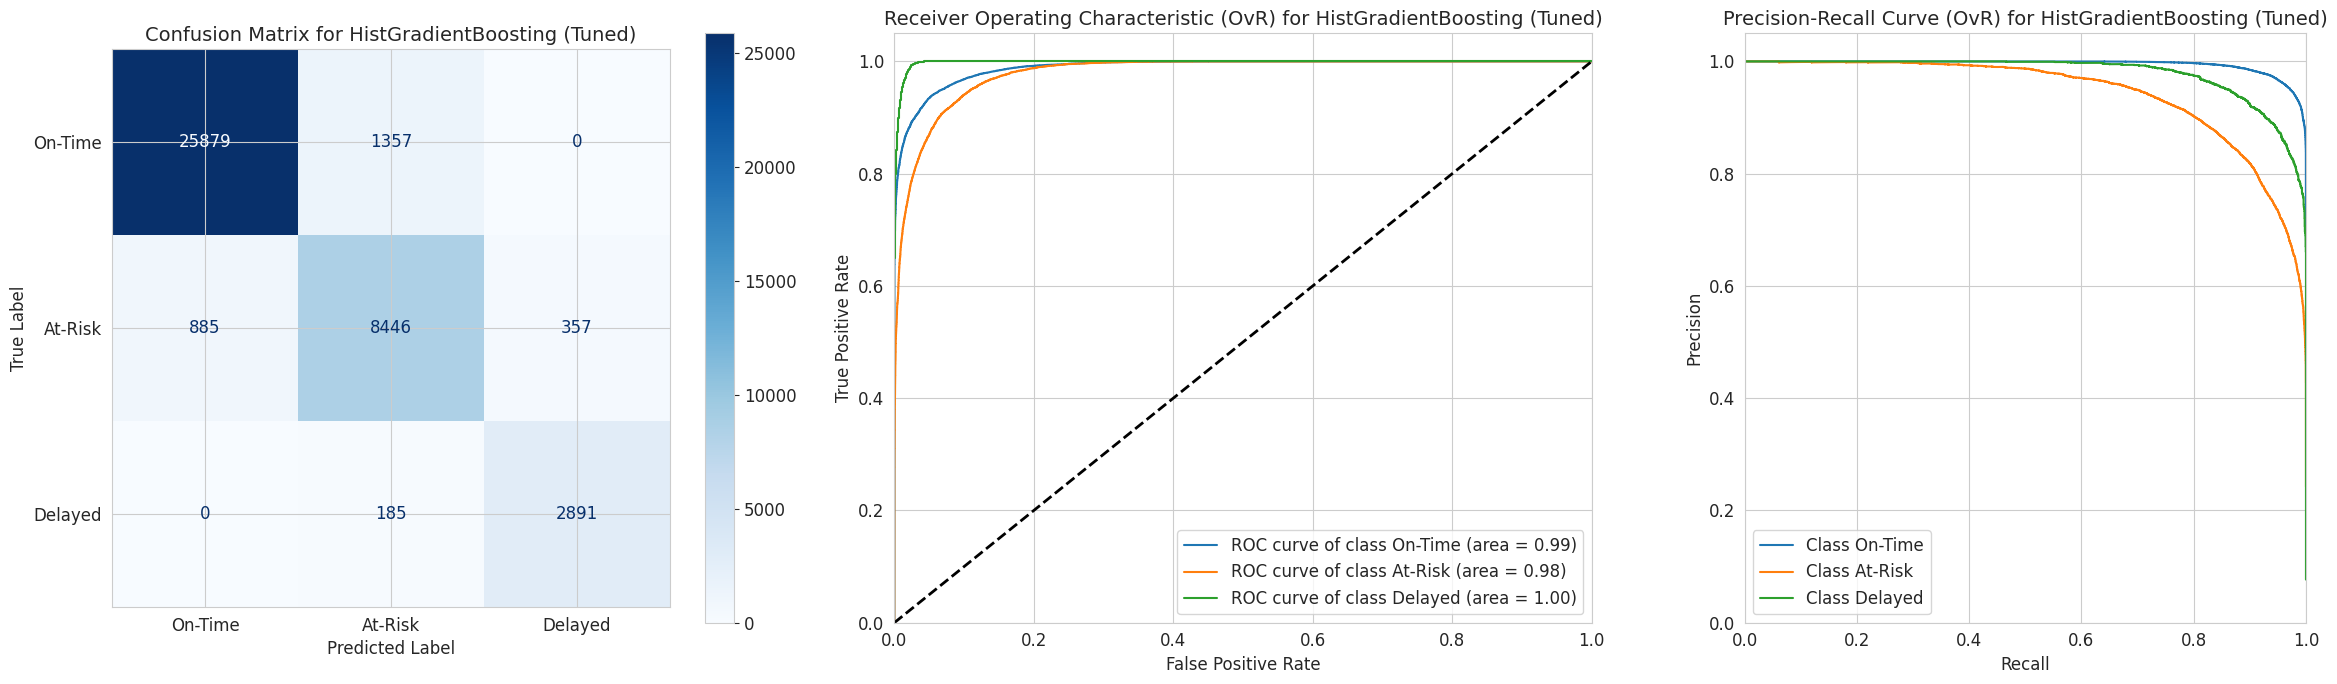


Evaluating LightGBM (Tuned)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report for LightGBM (Tuned):

              precision    recall  f1-score   support

     On-Time       0.97      0.94      0.96     27236
     At-Risk       0.83      0.88      0.85      9688
     Delayed       0.88      0.95      0.91      3076

    accuracy                           0.93     40000
   macro avg       0.89      0.92      0.91     40000
weighted avg       0.93      0.93      0.93     40000



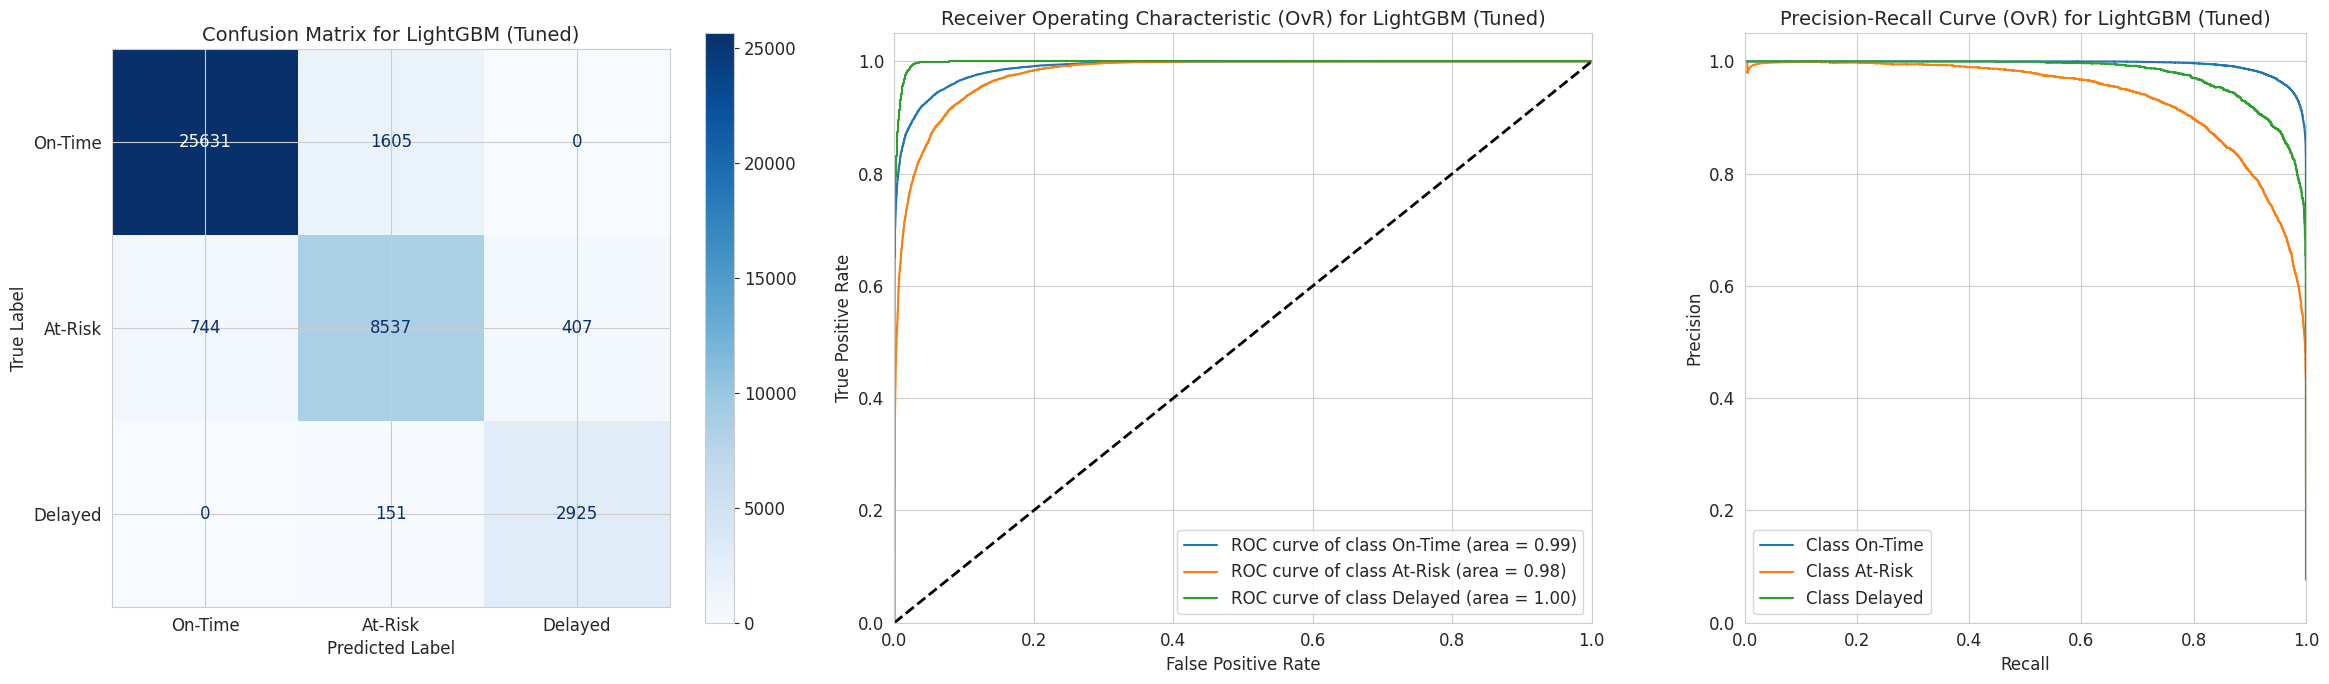

/tmp/ipython-input-3106384502.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, ax=ax, palette='viridis')


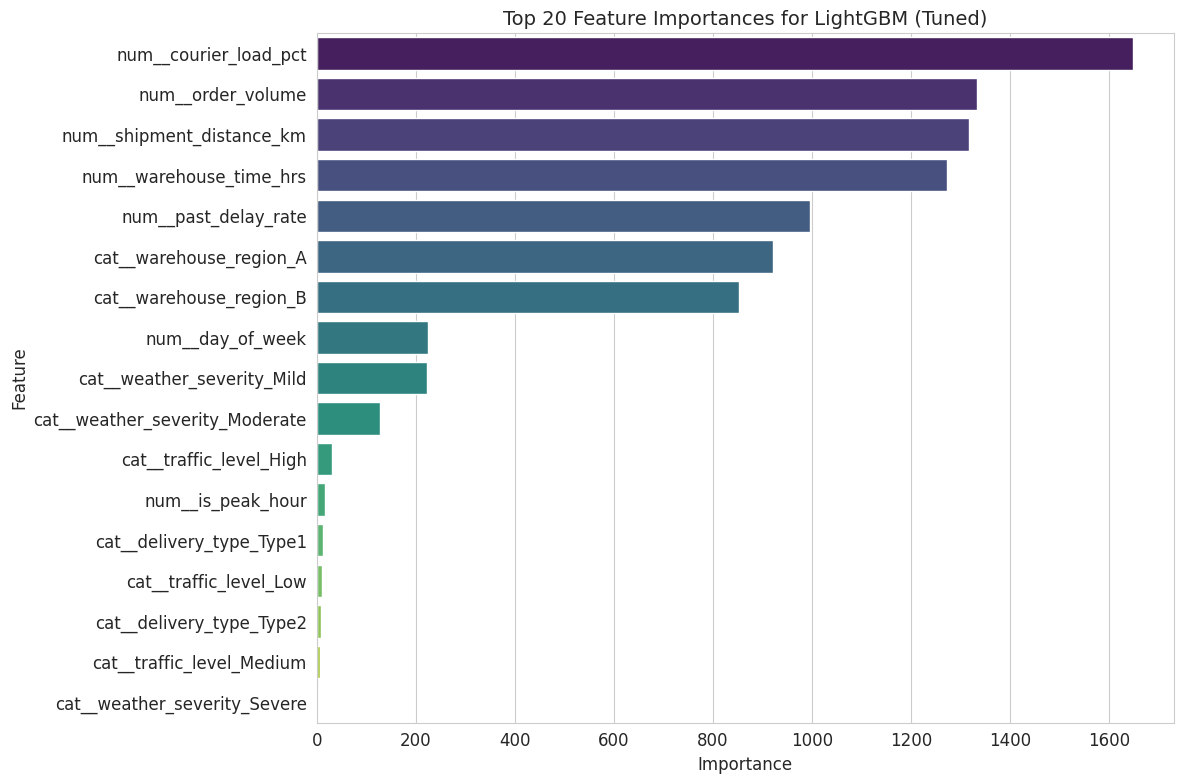


Evaluating XGBoost (Tuned)

Classification Report for XGBoost (Tuned):

              precision    recall  f1-score   support

     On-Time       0.97      0.93      0.95     27236
     At-Risk       0.81      0.88      0.85      9688
     Delayed       0.85      0.96      0.90      3076

    accuracy                           0.92     40000
   macro avg       0.88      0.92      0.90     40000
weighted avg       0.93      0.92      0.92     40000



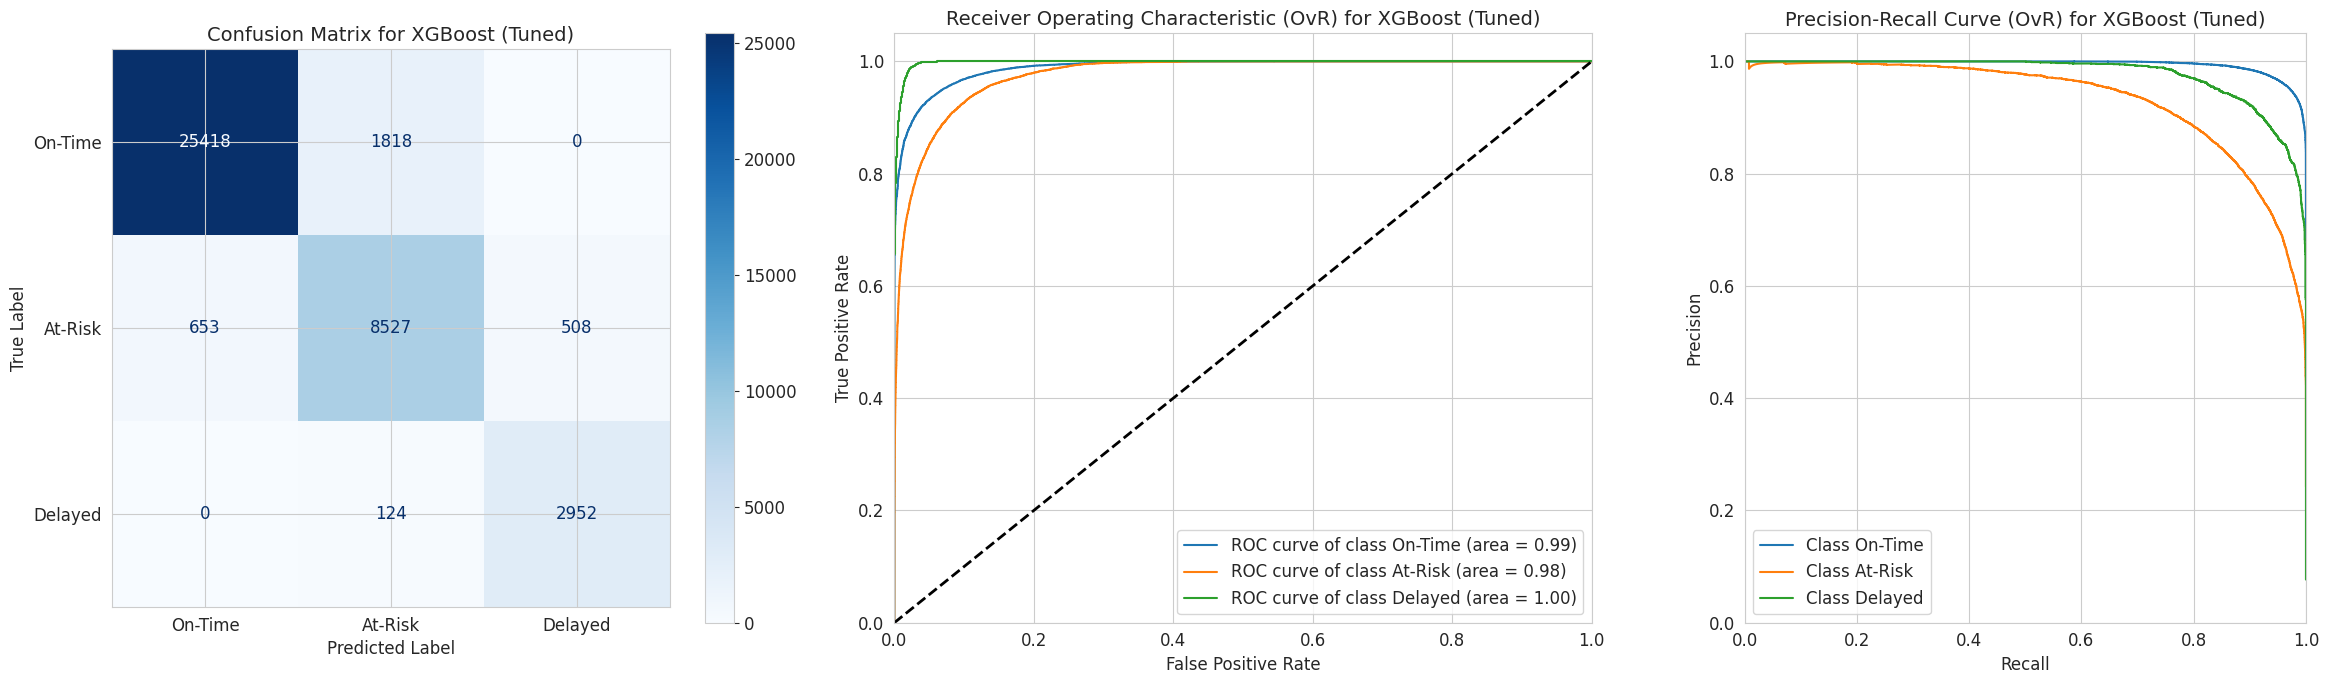

/tmp/ipython-input-3106384502.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, ax=ax, palette='viridis')


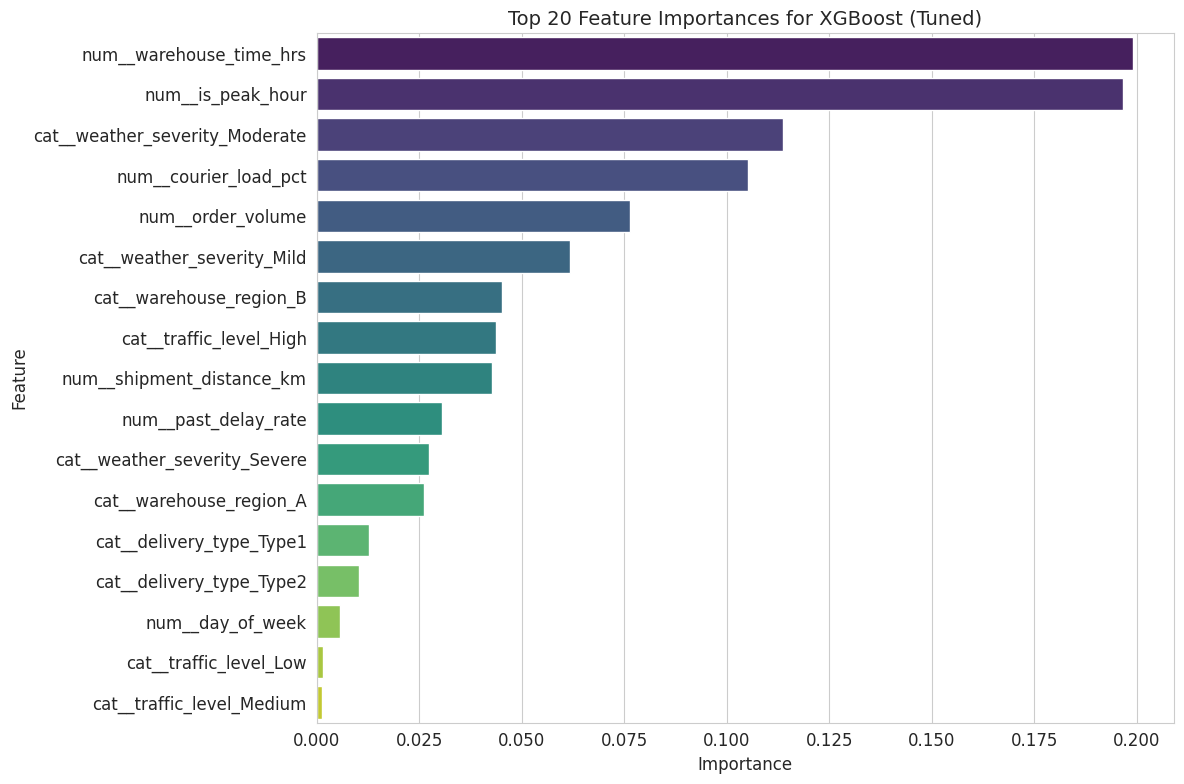

In [ ]:
for model_name, model in tuned_models.items():
    print(f"/n{'='*50}/nEvaluating {model_name}/n{'='*50}")

    # Make predictions and get probabilities
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # Classification Report
    print(f"/nClassification Report for {model_name}:/n")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    # Setup for plots
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    # Confusion Matrix
    plot_confusion_matrix(model_name, y_test, y_pred, CLASS_NAMES, axes[0])

    # ROC Curve
    plot_roc_curve(model_name, y_test, y_score, CLASS_NAMES, N_CLASSES, axes[1])

    # Precision-Recall Curve
    plot_precision_recall_curve(model_name, y_test, y_score, CLASS_NAMES, N_CLASSES, axes[2])

    plt.tight_layout()
    plt.show()

    # Feature Importance (only for LightGBM and XGBoost)
    if model_name in ["LightGBM (Tuned)", "XGBoost (Tuned)"]:
        fig, ax = plt.subplots(figsize=(12, 8))
        # Use the provided feature names list
        plot_feature_importance(model_name, model, feature_names_list, top_n=20, ax=ax)
        plt.show()